In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('sms.txt', sep='\t', header=None, names=['label', 'message'])

In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [4]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df.isnull().sum()

label      0
message    0
dtype: int64

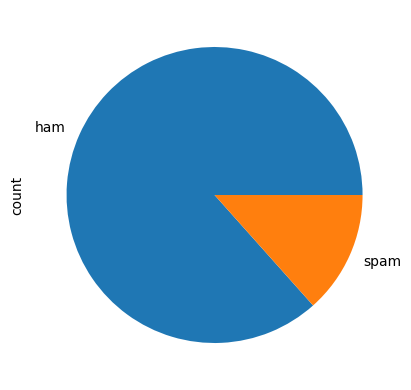

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(kind='pie', ax=ax)
plt.tight_layout()
plt.show()


In [7]:
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df.groupby(['message_length', 'word_count']).describe()

label                  message         \
                          count unique  top freq   count unique   
message_length word_count                                         
2              1              4      1  ham    4       4      1   
3              1              8      1  ham    8       8      4   
4              1              5      1  ham    5       5      2   
               2              1      1  ham    1       1      1   
5              1             11      1  ham   11      11      2   
...                         ...    ...  ...  ...     ...    ...   
588            125            2      1  ham    2       2      1   
611            103            1      1  ham    1       1      1   
629            109            1      1  ham    1       1      1   
790            162            1      1  ham    1       1      1   
910            171            1      1  ham    1       1      1   

                                                                              \
                                                                         top   
message_length word_count                                                      
2              1                                                          Ok   
3              1                                                         Ok.   
4              1                                                        Okie   
               2                                                        U 2.   
5              1                                                       Ok...   
...                                                                      ...   
588            125         Sad story of a Man - Last week was my b'day. M...   
611            103         How to Make a girl Happy? It's not at all diff...   
629            109         Indians r poor but India is not a poor country...   
790            162         The last thing i ever wanted to do was hurt yo...   
910            171         For me the love should start with attraction.i...   

                                
                          freq  
message_length word_count       
2              1             4  
3              1             4  
4              1             4  
               2             1  
5              1            10  
...                        ...  
588            125           2  
611            103           1  
629            109           1  
790            162           1  
910            171           1  

[1485 rows x 8 columns]

In [8]:
#clean duplicates + numeric target
before = len(df)
df=df.drop_duplicates(subset=['label', 'message']).reset_index(drop=True)
print(f"Removed {before-len(df)} duplicate rows")
df['target']=df['label'].map({'ham':0, 'spam':1})
df['target'].value_counts()

Removed 403 duplicate rows


target
0    4516
1     653
Name: count, dtype: int64

In [9]:
#Text preprocessing
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
import string
import re
STOPWORDS = ENGLISH_STOP_WORDS
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text =re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOPWORDS and len(word) > 1]
    return ' '.join(tokens)

df['cleaned_message'] = df['message'].apply(clean_text)
df[['message', 'cleaned_message']].head(10)

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word id like fun tb ...
6,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months entitled update latest colour mo...


In [10]:
#train test split
from sklearn.model_selection import train_test_split
X=df['cleaned_message']
y=df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#Vectorization
vectorizer_config = {
    'Count-Unigram': CountVectorizer(ngram_range=(1, 1)),
    'Count-Bigram': CountVectorizer(ngram_range=(1, 2)),
    'TFIDF-Unigram': TfidfVectorizer(ngram_range=(1, 1)),
    'TFIDF-Bigram': TfidfVectorizer(ngram_range=(1, 2)),
}
for name, vectorizer in vectorizer_config.items():
    X_train_vectorized = vectorizer.fit_transform(X_train)
    X_test_vectorized = vectorizer.transform(X_test)
    print(f"{name}: Train shape: {X_train_vectorized.shape}, Test shape: {X_test_vectorized.shape}")

Count-Unigram: Train shape: (4135, 7295), Test shape: (1034, 7295)
Count-Bigram: Train shape: (4135, 30190), Test shape: (1034, 30190)
TFIDF-Unigram: Train shape: (4135, 7295), Test shape: (1034, 7295)
TFIDF-Bigram: Train shape: (4135, 30190), Test shape: (1034, 30190)


In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
alpha_values = [0.1, 0.5, 1, 2, 5]
results = []
for name, vectorizer in vectorizer_config.items():
    X_train_vectorized = vectorizer.fit_transform(X_train)
    X_test_vectorized = vectorizer.transform(X_test)
    for alpha in alpha_values:
        model = MultinomialNB(alpha=alpha)
        model.fit(X_train_vectorized, y_train)
        y_pred = model.predict(X_test_vectorized)
        y_pred_proba = model.predict_proba(X_test_vectorized)[:, 1]
        results.append((name, alpha, accuracy_score(y_test, y_pred),precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred), confusion_matrix(y_test, y_pred), roc_auc_score(y_test, y_pred_proba)))
results_df = pd.DataFrame(results, columns=['Vectorizer', 'Alpha', 'Accuracy','Precision', 'Recall', 'F1 Score', 'Confusion Matrix', 'ROC AUC'])
results_df.sort_values(by='F1 Score', ascending=False, inplace=True)
print(results_df)

       Vectorizer  Alpha  Accuracy  Precision    Recall  F1 Score  \
15   TFIDF-Bigram    0.1  0.985493   0.991228  0.889764  0.937759   
8    Count-Bigram    2.0  0.980658   0.973451  0.866142  0.916667   
7    Count-Bigram    1.0  0.979691   0.949153  0.881890  0.914286   
6    Count-Bigram    0.5  0.978723   0.926829  0.897638  0.912000   
10  TFIDF-Unigram    0.1  0.978723   0.933884  0.889764  0.911290   
5    Count-Bigram    0.1  0.976789   0.905512  0.905512  0.905512   
2   Count-Unigram    1.0  0.976789   0.918699  0.889764  0.904000   
4   Count-Unigram    5.0  0.977756   0.981481  0.834646  0.902128   
1   Count-Unigram    0.5  0.975822   0.904762  0.897638  0.901186   
0   Count-Unigram    0.1  0.974855   0.891473  0.905512  0.898438   
9    Count-Bigram    5.0  0.976789   0.981308  0.826772  0.897436   
11  TFIDF-Unigram    0.5  0.976789   1.000000  0.811024  0.895652   
3   Count-Unigram    2.0  0.974855   0.917355  0.874016  0.895161   
16   TFIDF-Bigram    0.5  0.966151

In [14]:
#refit the best model
best_vectorizer_name, best_alpha = results_df.iloc[0]['Vectorizer'], results_df.iloc[0]['Alpha']
best_vectorizer = vectorizer_config[best_vectorizer_name]
X_train_vectorized = best_vectorizer.fit_transform(X_train)
X_test_vectorized = best_vectorizer.transform(X_test)
best_model = MultinomialNB(alpha=best_alpha)
best_model.fit(X_train_vectorized, y_train)
y_pred = best_model.predict(X_test_vectorized)
